## Import & Utils

In [1]:
import pandas as pd
from datasets import load_dataset
from tqdm import tqdm
import networkx as nx
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter


/home/rachele/LAST-JD/ESC_kg/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

dataset = load_dataset("rmignone/HUDOC-ESC", data_files="ESC_Corpus_Final.parquet")
node_df = dataset['train'].to_pandas()


Generating train split: 28638 examples [00:00, 71183.43 examples/s]


## Map types
maps the downloaded types into human-readable ones and adds column to df

In [5]:
type_map={'ADMIS': 'Case Admissibility',
 'CCASST': 'ECSR Finding',
 'CCREC' : 'CoM Recommendation',
 'CCRES' : 'CoM Resolution',
 'COREC' : 'CoM Recommendation',
 'CORES' : 'CoM Resolution',
 'CR' : 'Conclusion',
 'Conclusion' : 'Conclusion',
 'FOND' : 'Merit',
 'IMMED' : 'Immediate Measure',
 'OPCC' : 'Separate Opinion',
 'Ob' : 'Statement of Interpretation',
 'Op' : 'Separate Opinion',
 'STROUT': 'Strike Out'}

def map_document_type(raw_type):
    if pd.isna(raw_type):
        return []
    try:
        # Try direct mapping for single values
        return [type_map[raw_type]]
    except KeyError:
        # If direct mapping fails, assume it's a semicolon-separated string
        parts = [part.strip() for part in raw_type.split(';') if part.strip()]
        mapped_types = []
        for part in parts:
            if part in type_map:
                mapped_types.append(type_map[part])
            # If a part is not found in type_map, it will be skipped
        return mapped_types
    except TypeError: # Handle cases where raw_type might not be a string, e.g., numbers
        return []

node_df['document_type_text'] = node_df['raw_document_type'].apply(map_document_type)

## Get mentioned articles, Article Dictionaries
creates list of all articles mentioned by the charter-related documents

In [6]:

existing_articles= list(set([i for i in list(node_df.article) if i ==i]))

processed_articles = []
for article_entry in existing_articles:

    if article_entry:
        # Split by semicolon first
        semicolon_parts = article_entry.split(';')
        for part in semicolon_parts:
            # Then for each part, split by newline
            newline_parts = part.split('\n')
            for sub_part in newline_parts:
                stripped_sub_part = sub_part.strip()
                if stripped_sub_part:
                    # Now, also split by ':'
                    colon_parts = stripped_sub_part.split(':')
                    for colon_part in colon_parts:
                        # And then by ','
                        comma_parts = colon_part.split(',')
                        for comma_part in comma_parts:
                            # Finally, split by '.'
                            dot_parts = comma_part.split('.')
                            # Extend the main list with non-empty, stripped parts
                            processed_articles.extend([p.strip() for p in dot_parts if p.strip()])


# Remove repetitions and assign to a variable to be displayed
unique_articles = list(set(processed_articles))
unique_articles

['91-100-163',
 '91-140-163',
 '19-12-163',
 '17-01-000',
 '02-01-000',
 '06-04-000',
 '91-123-163',
 '03-02-000',
 '91-113-163',
 '17-00-000',
 '18-01-000',
 '06-00-000',
 '91-178-163',
 '02-05-000',
 '04-02-000',
 '19-07-000',
 '07-00-000',
 '02-03-000',
 '91-120-163',
 '06-02-000',
 '91-151-163',
 '91-158-163',
 '19-01-000',
 '01-04-000',
 '24-00-163',
 '07-10-000',
 '31-00-163',
 '09-00-000',
 '91-165-163',
 '11-02-000',
 '17-00-035',
 '07-08-000',
 '19-05-000',
 '03-00-000',
 '10-02-000',
 '91-153-163',
 '09-01-000',
 '03-02-163',
 '91-149-163',
 '91-162-163',
 '14-02-000',
 '91-124-163',
 '91-172-163',
 '19-04-000',
 '17-02-163',
 '91-202-163',
 '07-03-000',
 '91-129-163',
 '02-00-000',
 '08-01-000',
 '91-198-163',
 '02-06-163',
 '04-03-000',
 '26-02-163',
 '01-02-000',
 '12-04-00',
 '08-00-000',
 '08-10-000',
 '23-00-000',
 '13-04-000',
 '02-04-163',
 '19-02-000',
 '93-000-000',
 '01-05-000',
 '91-212-163',
 '91-177-163',
 '91-161-163',
 '11-00-000',
 '02-02-000',
 '07-09-000',


In [7]:
letter_map={
    'E': 91,
    'F': 92,
    'G': 93,
    'H': 94,
    'I': 95,
    'J': 96,
    'K': 97,
    'L': 98,
    'M': 99,
    'N': 100,
    'O': 101,
    'P': 102
}

#### KG

In [8]:
with open('appendix.json') as f:
    appendix_nodes= json.load(f)

for node in appendix_nodes:
  node.pop('mentions')
  node.pop('type')
  node['base_id'] = node.pop('id')
  node['available_languages'] = ['EN' , 'FR']
  node['document_type_text']= ['Charter', 'Appendix']

In [9]:
def find_corresponding(id):
  res=[]
  if len(id.split('-'))>=4:
    base_id= '-'.join(id.split('-')[1:-1])
    if not any([c.isalpha() for c in base_id if c!= '-']):
        res= [i for i in unique_articles if base_id in i]
    else:
      try:
        letter= id.split('-')[1].upper()
        if letter and letter in letter_map:
          res= [i for i in unique_articles if i.startswith(str(letter_map[letter]))]
      except:
        print('No matches found for: ', id)

  return res


In [10]:
with open('graph_nodes.json') as f:
    knowledge_graph = json.load(f)


for node in knowledge_graph:
  node['available_languages']= ['EN', 'FR']
  node['publication_date']= '1996'
  node['document_type_text']= ['Charter']

  if node['id'].startswith('P'):
    node['found_as']= find_corresponding(node['id'])
  else:
    node['found_as']= []
  node['base_id'] = node.pop('id')


#### Reverse dict

In [11]:
# 1. Build the map once using a dictionary comprehension
article_to_id = {
    article: item['base_id']
    for item in knowledge_graph
    for article in item.get('found_as', [])
}

# 2. Query it instantly as many times as you want
target_article = '91-199-163'
result_id = article_to_id.get(target_article)

print(result_id) # Output: P5-E-00-163

P5-E-00-163


## Create Nodes

### Create Complaint Nodes

In [12]:
complaints= list(node_df[node_df['document_type_text'].apply(lambda x: 'Case Admissibility' in x)]['base_id'])
complaint_ids= ['-'.join(i.split('-')[:-1]) for i in complaints]

complaint_nodes= []
for i in complaint_ids:
  case_adm= node_df[node_df['base_id']== i+'-dadmiss']

  if case_adm.empty:
    case_adm= node_df[node_df['base_id']== i+'-dadmissandmerits']

  if case_adm.empty:
    case_adm= node_df[node_df['base_id']== i+'-dadmissandimmed']

  if not case_adm.empty:
    # Ensure that Series are converted to their underlying scalar values or lists
    comp_node= {'base_id': i,
                'available_languages': case_adm['available_languages'].iloc[0], # Extract the list from the Series
                'publication_date':case_adm['publication_date'].iloc[0],      # Extract the scalar from the Series
                'document_type_text': ['Complaint'],
                'state_party': case_adm['state_party'].iloc[0]}             # Extract the scalar from the Series
    complaint_nodes.append(comp_node)


In [13]:
selected_node_columns = ['base_id', 'available_languages', 'publication_date', 'document_type_text', 'state_party']
nodes = []
for index, row in node_df.iterrows():
    node_data = {}
    for col in selected_node_columns:
        value = row[col]
        # If the value is a Pandas Series, extract its content
        if isinstance(value, pd.Series):
            if not value.empty:
                node_data[col] = value.iloc[0]
            else:
                node_data[col] = None # Or an appropriate default value for empty series
        elif isinstance(value, np.ndarray):
            node_data[col] = value.tolist()
        else:
            node_data[col] = value
    nodes.append(node_data)

In [14]:
nodes.extend(complaint_nodes)
nodes.extend(knowledge_graph)
nodes.extend(appendix_nodes)
all_base_ids= list(node_df['base_id'])

/tmp/ipykernel_1576107/2141589852.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_series.index, y=counts_series.values, palette='viridis')


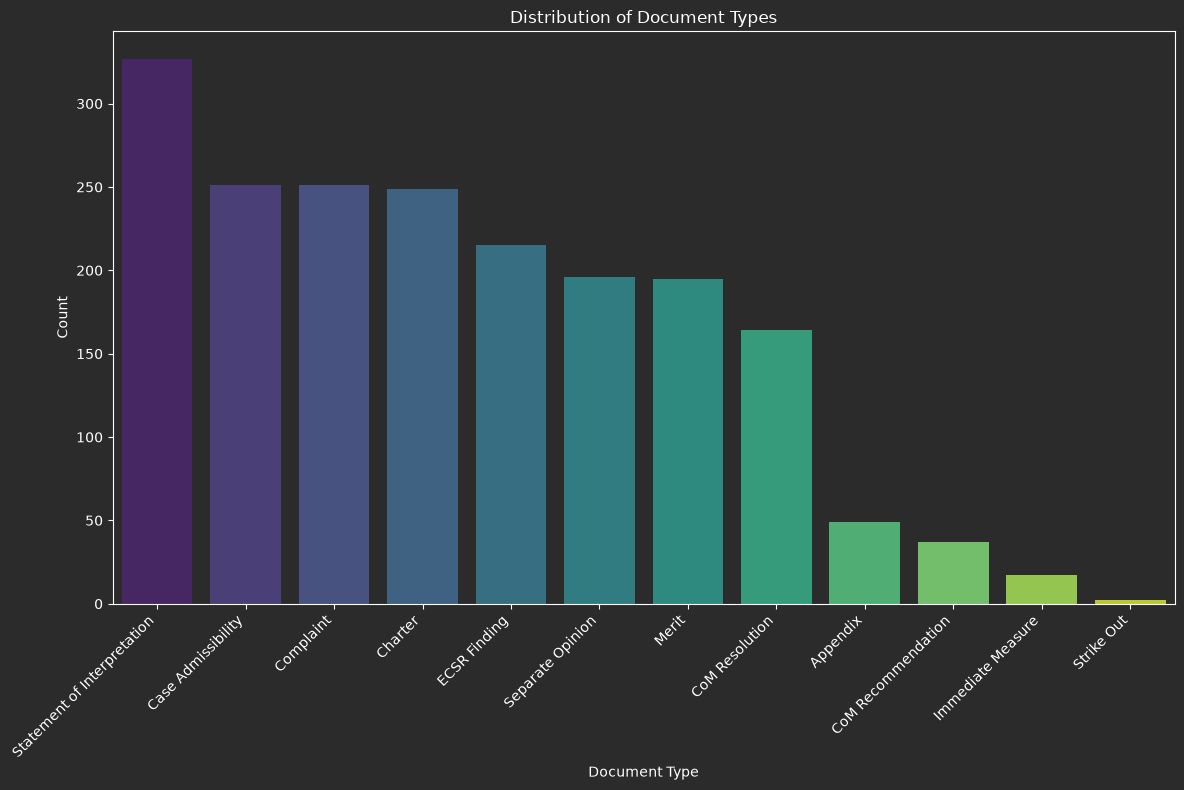

In [26]:
# Flatten the list of lists in 'document_type_text'
types= [i['document_type_text'] for i in nodes]
all_document_types = [item for sublist in types if isinstance(sublist, list) for item in sublist]
no_conclusions = [item for sublist in types if isinstance(sublist, list) for item in sublist if item != 'Conclusion']

# Count the occurrences of each document type
# type_counts = Counter( no_conclusions)
type_counts = Counter(no_conclusions)

# Convert to a pandas Series for easier plotting
counts_series = pd.Series(type_counts).sort_values(ascending=False)

# Plot the distribution
plt.figure(figsize=(12, 8))
sns.barplot(x=counts_series.index, y=counts_series.values, palette='viridis')
plt.xlabel('Document Type')
plt.ylabel('Count')
plt.title('Distribution of Document Types')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Create Edges

In [16]:
all_base_ids= [i['base_id'] for i in nodes]

def create_edge(source,  target,  key, source_art: bool = False, target_art: bool = False):
    if source_art:
      source= article_to_id[source.strip()]
    if target_art:
      target= article_to_id[target.strip()]

    if source in all_base_ids and target in all_base_ids:
        return {'source': source, 'target': target, 'key': key}
    else:
      return {}



In [17]:

edges=[]
# all_base_ids= list(node_df['base_id'])

for index, row in tqdm(node_df.iterrows()):
    # base_id = row['base_id'].strip() if isinstance(row['base_id'], str) else row['base_id']
    base_id= row['base_id']
    document_type_text = row['document_type_text']

    if 'Conclusion' in document_type_text:

      #assesses compliance of Doc Section
      if row['article'] is not None and isinstance(row['article'], str) and row['article'].strip() != '': # Check if article is not None or empty string
          edge= create_edge(base_id, row['article'].strip(), 'assesses_compliance_of', target_art=True)
          if edge:
            edges.append(edge)


    # complaint declared admissible by case admissibility
    if 'Case Admissibility' in document_type_text:
      complaint_str= '-'.join(base_id.split('-')[:-1])
      if complaint_str in complaint_ids :
        edge= create_edge(complaint_str, base_id, 'declared_admissible_by')
        if edge:
          edges.append(edge)

        #charter invoked by complaint
        if row['article'] is not None and isinstance(row['article'], str): # Ensure article is a string and not None
            for segments in row['article'].split(':'):
                for segment in segments.split('\n'):
                    for seg in segment.split(','):
                      for art in seg.split(';'):
                        if art.strip() != '' and art in article_to_id: # Ensure article part is not an empty string
                            edge= create_edge(art.strip(), complaint_str, 'invoked_by', source_art=True)
                            if edge:
                              edges.append(edge)

    # Rec/Res/Finding assess compliance of Charter
    if 'CoM Recommendation' in document_type_text or 'CoM Resolution' in document_type_text or 'ECSR Finding' in document_type_text:
      if row['article'] is not None and isinstance(row['article'], str): # Ensure article is a string and not None
            for segments in row['article'].split(':'):
                for segment in segments.split('\n'):
                    for seg in segment.split(','):
                      for art in seg.split(';'):
                          if art.strip() != '' and art in article_to_id: # Ensure article part is not an empty string
                            edge= create_edge(base_id, art.strip(), 'assesses_compliance_of', target_art=True)
                            if edge:
                              edges.append(edge)



    if 'Merit' in document_type_text:

      # Complaint adjudicated by Case Merit
      complaint_str= '-'.join(base_id.split('-')[:-1])
      if complaint_str in complaint_ids:
        edge= create_edge(complaint_str, base_id, 'adjudicated_by')
        if edge:
          edges.append(edge)

        # Article adjudicated by Complaint
        if row['article'] is not None and isinstance(row['article'], str):
            for segments in row['article'].split(':'):
                for segment in segments.split('\n'):
                    for seg in segment.split(','):
                      for art in seg.split(';'):
                        if art.strip() != '' and art in article_to_id:
                          edge= create_edge(art.strip(), complaint_str, 'invoked_by', source_art=True)
                          if edge:
                            edges.append(edge)


    if 'Immediate Measure' in document_type_text:

      #Article protected_by Immediate Measure
      if row['article'] is not None and isinstance(row['article'], str):
         for segments in row['article'].split(':'):
                for segment in segments.split('\n'):
                    for seg in segment.split(','):
                      for art in seg.split(';'):
                          if art.strip() != '' and art in article_to_id:
                            edge= create_edge(art.strip(), base_id, 'protected_by', source_art=True)
                            if edge:
                              edges.append(edge)

      #Complaint requires Immediate Measure
      complaint_str= '-'.join(base_id.split('-')[:-1])
      if complaint_str in complaint_ids:
        edge= create_edge(complaint_str, base_id, 'requires')
        if edge:
          edges.append(edge)



    if 'Separate Opinion' in document_type_text:
      #Doc Section interpreted_divergently_by Separate Opinion
      if row['article'] is not None and isinstance(row['article'], str):
       for segments in row['article'].split(':'):
        for segment in segments.split('\n'):
            for seg in segment.split(','):
              for art in seg.split(';'):
                    if art.strip() != '' and art in article_to_id:
                      edge= create_edge(art.strip(), base_id, 'interpreted_divergently_by', source_art=True)
                      if edge:
                        edges.append(edge)


      #Merits interpreted_divergently_by Separate Opinion
      if row['complaint_number'] is not None and isinstance(row['complaint_number'], str):
        split= row['complaint_number'].split('/')

        if len(split)>1:
          if f'cc-{split[0]}-{split[1]}-dmerits' in all_base_ids:
            edge= create_edge(f'cc-{split[0]}-{split[1]}-dmerits', base_id, 'interpreted_divergently_by')
            if edge:
              edges.append(edge)



    if 'Statement of Interpretation' in document_type_text:
      #Doc Section interpreted_by Statement of Interpretation
      if row['article'] is not None and isinstance(row['article'], str):
          for segments in row['article'].split(':'):
            for segment in segments.split('\n'):
                for seg in segment.split(','):
                  for art in seg.split(';'):
                      if art.strip() != '' and art in article_to_id:
                        edge= create_edge(art.strip(), base_id, 'interpreted_by', source_art=True)
                        if edge:
                          edges.append(edge)


    if 'Strike Out' in document_type_text:
      if row['complaint_number'] is not None and isinstance(row['complaint_number'], str):
        split= row['complaint_number'].split('/')

        if len(split)>1:
          if f'cc-{split[0]}-{split[1]}-dadmiss' in all_base_ids:
            edge= create_edge(base_id, f'cc-{split[0]}-{split[1]}-dadmiss', 'rejects')
            if edge:
                edges.append(edge)



print('Edges', len(edges))

# Convert list of dictionaries to a set of frozensets for de-duplication, I'll convert each dictionary into a hashable format (like a frozenset of its key-value $0
unique_edges_frozensets = {frozenset(d.items()) for d in edges}

# Convert frozensets back to dictionaries
edges = [dict(fs) for fs in unique_edges_frozensets]

print(f"Number of unique edges: {len(edges)}")

9738it [00:03, 2864.48it/s]

No article found for:  20210325-125326
No article found for:  20210325-125333
No article found for:  20210330-144417
No article found for:  20210330-144551
No article found for:  20210330-144648
No article found for:  20210330-144841


11303it [00:03, 3587.39it/s]

No article found for:  CCASST/013/2002 --> ['ECSR Finding']
No article found for:  CCASST/015/2003 --> ['ECSR Finding']
No article found for:  CCASST/027/2004 --> ['ECSR Finding']
No article found for:  CCASST/030/2005 --> ['ECSR Finding']
No article found for:  CCASST/031/2005 --> ['ECSR Finding']
No article found for:  CCASST/033/2006 --> ['ECSR Finding']
No article found for:  CCASST/038/2006 --> ['ECSR Finding']
No article found for:  CCASST/039/2006 --> ['ECSR Finding']
No article found for:  CCASST/041/2007 --> ['ECSR Finding']
No article found for:  CCASST/046/2007 --> ['ECSR Finding']
No article found for:  CCASST/049/2008 --> ['ECSR Finding']
No article found for:  CCASST/051/2008 --> ['ECSR Finding']
No article found for:  CCASST/052/2008 --> ['ECSR Finding']
No article found for:  CCASST/053/2008 --> ['ECSR Finding']
No article found for:  CCASST/057/2009 --> ['ECSR Finding']
No article found for:  CCASST/058/2009 --> ['ECSR Finding']
No article found for:  CCASST/061/2010 -

27091it [00:09, 2827.79it/s]


KeyboardInterrupt: 

### Appendix Edges


In [ ]:
appendix_edges=[]
len_before= len(edges)
for i in appendix_nodes:
  for j in i['linked_to']:
    appendix_edges.append({
        'source': j,
        'target': i['base_id'],
        'key': 'complemented_by'
    })

edges.extend(appendix_edges)

print(len(edges) - len_before, 'added appendix edges')

### Charter Edges

In [ ]:
charter_edges=[]
len_before= len(edges)
for i in knowledge_graph:
  for j in i['children']:
    charter_edges.append({
        'source': i['base_id'],
        'target': j,
        'key': 'has_part'
    })
  i.pop('children')



edges.extend(charter_edges)
print(len(edges) - len_before, 'added charter edges')

## Graph Creation

In [ ]:
# 2. Initialize the Property Graph
G = nx.MultiDiGraph()

# 3. Add Nodes with Properties
for node_data in nodes:
    # Isolate the base_id to use as the NetworkX node identifier
    node_id = node_data['base_id']

    # Create a copy of the dictionary without the base_id to use as properties
    properties = {k: v for k, v in node_data.items() if k != 'base_id'}

    # Optional: Convert numpy arrays and single-item lists to standard types
    # to make it easier for LLM prompt generation later
    if 'available_languages' in properties and isinstance(properties['available_languages'], np.ndarray):
        properties['available_languages'] = properties['available_languages'].tolist()

    # Add to graph
    G.add_node(node_id, **properties)

# 4. Add Edges with Properties
for edge_data in edges:
    # NetworkX add_edge takes (source, target, **attributes)
    G.add_edge(
        edge_data['source'],
        edge_data['target'],
        relationship_type=edge_data.pop('key') # Renaming 'key' to avoid conflicts
    )

In [ ]:
# Convert the graph to a node-link data format (dictionary)
graph_data = nx.node_link_data(G)

# Save the dictionary to a JSON file
with open('graph.json', 'w') as f:
    json.dump(graph_data, f, indent=4)

In [ ]:
import networkx as nx
import time
from collections import Counter

def analyze_large_network(G):
    print(f"--- Starting Analysis on {G.number_of_nodes()} Nodes ---")
    start_time = time.time()

    # 1. Basic Topographical Metrics
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    density = nx.density(G)

    print(f"Nodes: {num_nodes:,}")
    print(f"Edges: {num_edges:,}")
    print(f"Graph Density: {density:.6f}")

    # 2. Degree Analysis (Fast)
    degrees = [degree for node, degree in G.degree()]
    avg_degree = sum(degrees) / num_nodes
    max_degree = max(degrees)
    max_degree_node= sorted(G.degree(), key=lambda tup: tup[1], reverse=True)[0]
    print(f"Average Degree: {avg_degree:.2f}")
    print(f"Maximum Degree: {max_degree} for node {max_degree_node}")

    # 3. Component Analysis (Fast)
    if nx.is_directed(G):
        components = list(nx.weakly_connected_components(G))
    else:
        components = list(nx.connected_components(G))

    giant_component_size = len(max(components, key=len))
    print(f"Number of Connected Components: {len(components)}")
    print(f"Giant Component Size: {giant_component_size:,} nodes ({giant_component_size/num_nodes*100:.1f}%)")

    # 4. Centrality (Using fast algorithms)
    print("\n--- Calculating Top Hubs (Degree Centrality) ---")
    deg_centrality = nx.degree_centrality(G)
    top_5_hubs = sorted(deg_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
    for node, score in top_5_hubs:
        print(f"Node {node}: Score {score:.4f}")

    # 5. PageRank (Excellent for large graphs, scales much better than Betweenness)
    print("\n--- Calculating PageRank ---")
    pagerank_scores = nx.pagerank(G, alpha=0.85)
    top_5_pr = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:5]
    for node, score in top_5_pr:
        print(f"Node {node}: PR Score {score:.6f}")

    print(f"\nAnalysis complete in {time.time() - start_time:.2f} seconds.")

# Example usage:

analyze_large_network(G)

## Degree Distribution

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

def plot_publication_degree_distribution(G, filename='degree_distribution.png'):
    # 1. Extract degrees, filtering out isolated nodes (degree 0) for log scale
    degrees = [degree for node, degree in G.degree() if degree > 0]

    if not degrees:
        print("Graph has no edges.")
        return

    # 2. Calculate probabilities P(k) and sort them
    degree_counts = Counter(degrees)
    total_nodes = len(degrees)

    # Sort the dictionary items by the degree (the key) in ascending order
    sorted_degree_counts = sorted(degree_counts.items())

    # Extract the sorted X and Y arrays
    x = np.array([item[0] for item in sorted_degree_counts])
    y = np.array([item[1] for item in sorted_degree_counts]) / total_nodes  # Normalize to fraction

    x = np.array(list(degree_counts.keys()))
    y = np.array(list(degree_counts.values())) / total_nodes  # Normalize to fraction

    # 3. Set up a publication-ready figure (300 DPI is standard for print)
    plt.figure(figsize=(8, 6), dpi=300)

    # 4. Plot the data
    # Using a subtle color and edge outline for clarity
    plt.scatter(x, y, color='#2b8cbe', alpha=0.8, edgecolor='black', s=50, zorder=2)

    # 5. Set logarithmic scales
    plt.xscale('log')
    plt.yscale('log')

    # 6. Styling and Typography
    plt.xlabel('Degree, $k$', fontsize=14)
    plt.ylabel('Probability, $P(k)$', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # 7. Clean up the aesthetics (remove top and right borders)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Add a faint grid behind the points for readability
    plt.grid(True, which="major", color='gray', linestyle='-', alpha=0.15, zorder=1)

    plt.tight_layout()

    # 8. Save the high-resolution image and display
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"Plot saved successfully as {filename}")
    plt.show()

# Run the function on your graph
plot_publication_degree_distribution(G)

In [ ]:
import powerlaw
import warnings

def test_power_law(G):
    print("Extracting degrees...")
    # Get degrees, ignoring isolated nodes (degree 0) because log(0) is undefined
    degrees = [degree for node, degree in G.degree() if degree > 0]

    if not degrees:
        print("Graph has no edges.")
        return

    print("Fitting distribution using Maximum Likelihood Estimation (MLE)...")
    # Suppress runtime warnings from the powerlaw package fitting process
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fit = powerlaw.Fit(degrees, discrete=True)

    # Extract the estimated exponent (alpha is equivalent to gamma)
    gamma = fit.alpha
    xmin = fit.xmin

    print(f"\n--- Power Law Fit Results ---")
    print(f"Estimated scaling exponent (gamma): {gamma:.4f}")
    print(f"Minimum degree threshold (x_min): {xmin}")

    # Check if gamma falls in the real-world interval
    if 2 < gamma < 3:
        print("Verdict: The exponent falls within the expected real-world interval (2 < gamma < 3).")
    else:
        print("Verdict: The exponent is OUTSIDE the typical scale-free interval (2 < gamma < 3).")

    print("\n--- Goodness of Fit vs Alternatives ---")
    # Compare power law against an exponential distribution
    # R is the log-likelihood ratio. Positive R means power law is a better fit.
    # p is the p-value. If p < 0.05, the result is statistically significant.
    R_exp, p_exp = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)

    print(f"Power Law vs Exponential: Log-likelihood ratio = {R_exp:.4f}, p-value = {p_exp:.4f}")
    if R_exp > 0 and p_exp < 0.05:
        print("Result: The degree distribution is mathematically much more likely to be a Power Law than an Exponential distribution.")
    else:
        print("Result: Cannot definitively rule out an Exponential distribution.")

    # Compare power law against a log-normal distribution
    R_log, p_log = fit.distribution_compare('power_law', 'lognormal', normalized_ratio=True)

    print(f"\nPower Law vs Log-Normal: Log-likelihood ratio = {R_log:.4f}, p-value = {p_log:.4f}")
    if R_log > 0 and p_log < 0.05:
        print("Result: The degree distribution is mathematically much more likely to be a Power Law than a Log-Normal distribution.")
    elif R_log < 0 and p_log < 0.05:
        print("Result: The network actually follows a Log-Normal distribution better than a Power Law.")
    else:
        print("Result: The statistical difference between Power Law and Log-Normal is insignificant (this is very common in empirical networks).")

# Run the test
# components = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
# giant_component = G.subgraph(components[0])
test_power_law(G)

In [ ]:
import json
import re
import networkx as nx
import pandas as pd

# ---------------------------------------------------------
# 1. Load the Graph from JSON
# ---------------------------------------------------------
with open("graph.json", "r") as f:
    data = json.load(f)

# Parse standard NetworkX node-link format
G = nx.node_link_graph(data)

# ---------------------------------------------------------
# 2. Identify Article Nodes
# ---------------------------------------------------------
# Criteria: 'Charter' in document_type_text AND id matches P\d-\d\d-00-163
article_pattern = re.compile(r"P\d-\d\d-00-163")
article_pattern1 = re.compile(r"P\d-[a-zA-Z]-00-163")
article_nodes = set()

for node, attr in G.nodes(data=True):
    doc_types = attr.get("document_type_text", [])
    node_id = str(attr.get("id", node))

    if isinstance(doc_types, list) and "Charter" in doc_types:
        if article_pattern.search(node_id):
            article_nodes.add(node)
        if article_pattern1.search(node_id):
            article_nodes.add(node)

print(f"Identified {len(article_nodes)} target Article nodes.")

# ---------------------------------------------------------
# 3. Map Subparts to Parent Articles (has_part taxonomy)
# ---------------------------------------------------------
# Extract all 'has_part' edges regardless of attribute key ('relation', 'type', 'label', etc.)
has_part_edges = []
for u, v, d in G.edges(data=True):
    edge_type = d.get("relationship_type")
    if edge_type == "has_part":
        has_part_edges.append((u, v))

taxonomy_graph = nx.DiGraph(has_part_edges)

node_mapping = {}
for article in article_nodes:
    if article in taxonomy_graph:
        # Find all nested children/subparts under this article
        descendants = nx.descendants(taxonomy_graph, article)
        for subpart in descendants:
            node_mapping[subpart] = article

# ---------------------------------------------------------
# 4. Aggregate Subparts & Clean Graph
# ---------------------------------------------------------
# Relabel nodes to merge subparts into their parent Article node
G_aggregated = nx.relabel_nodes(G, node_mapping, copy=True)

# Remove self-loops created by aggregating internal 'has_part' edges
G_aggregated.remove_edges_from(nx.selfloop_edges(G_aggregated))

# Convert to a simple directed graph (DiGraph) for shortest-path / spectral metrics
G_simple = nx.DiGraph(G_aggregated)

# ---------------------------------------------------------
# 5. Compute Centrality Metrics
# ---------------------------------------------------------
print("Calculating centrality metrics...")

# 1. Degree Centralities
in_degree = nx.in_degree_centrality(G_aggregated)
out_degree = nx.out_degree_centrality(G_aggregated)

# 2. PageRank (Influence based on incoming references)
try:
    pagerank = nx.pagerank(G_aggregated, alpha=0.85)
except Exception:
    pagerank = {}

# 3. Betweenness Centrality (Bridge / Brokerage role)
betweenness = nx.betweenness_centrality(G_simple)

# 4. Closeness Centrality (Accessibility / Proximity)
closeness = nx.closeness_centrality(G_simple)

# 5. HITS Authority Score (Relevance as an authoritative source)
try:
    _, authority = nx.hits(G_simple, max_iter=1000)
except Exception:
    authority = {}

# 6. Eigenvector Centrality
try:
    eigenvector = nx.eigenvector_centrality(G_simple, max_iter=1000)
except Exception:
    eigenvector = {}

# ---------------------------------------------------------
# 6. Compile & Display Results for Article Nodes
# ---------------------------------------------------------
results = []
for article in article_nodes:
    if article in G_aggregated:
        results.append({
            "Article ID": article,
            "In-Degree": round(in_degree.get(article, 0), 4),
            "Out-Degree": round(out_degree.get(article, 0), 4),
            "PageRank": round(pagerank.get(article, 0), 4),
            "Betweenness": round(betweenness.get(article, 0), 4),
            "Closeness": round(closeness.get(article, 0), 4),
            "Authority": round(authority.get(article, 0), 4),
            "Eigenvector": round(eigenvector.get(article, 0), 4)
        })

df = pd.DataFrame(results)

# Sort by PageRank (or In-Degree) in descending order
df = df.sort_values(by="PageRank", ascending=False).reset_index(drop=True)

# Display top results
print("\n--- Article Centrality Summary ---")
print(df.to_string(index=False))

# Optional: Export results to CSV
df.to_csv("all_article_centralities.csv", index=False)
print("\nResults exported to 'article_centralities.csv'.")

In [ ]:
G.out_edges('ROOT-163', data=True)

In [ ]:
components = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
unlinked=[list(i)[0] for i in components if len(i) == 1 ]
print(f'CI SONO:\n {len(unlinked)} NODI ISOLATI PERCHÉ NON HANNO ARTICOLI\n')

